<a href="https://colab.research.google.com/github/Aishatoo07/AissatouDieng_small_projects/blob/main/Coffee_Shop_SQL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

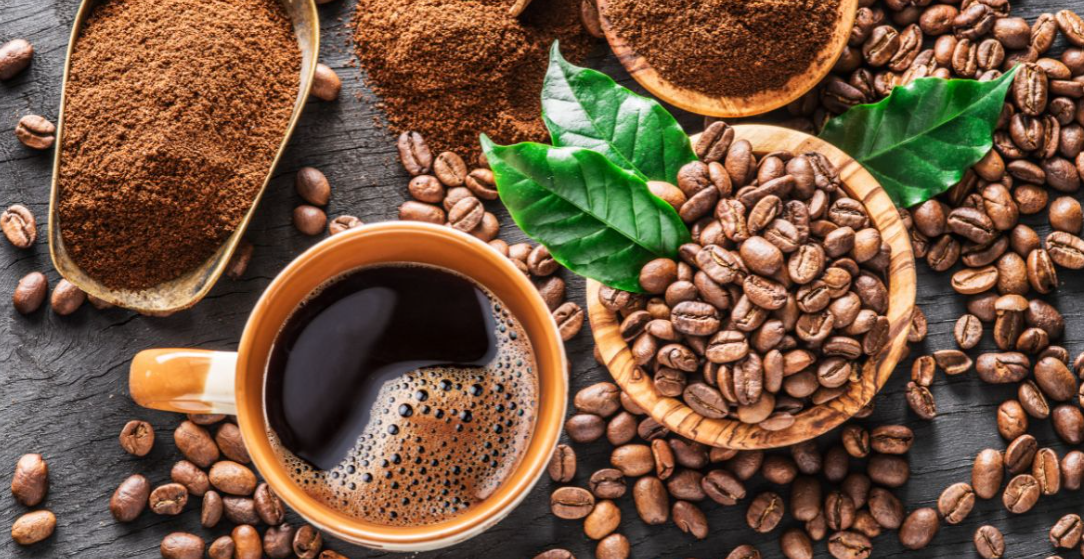

In [2]:
# Install faker
!pip install faker -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 12.9 MB/s eta 0:00:00


In [4]:
#Create database and tables
import sqlite3

conn = sqlite3.connect("coffee_shop.db")
cur = conn.cursor()

cur.executescript("""
DROP TABLE IF EXISTS order_items;
DROP TABLE IF EXISTS orders;
DROP TABLE IF EXISTS inventory;
DROP TABLE IF EXISTS products;
DROP TABLE IF EXISTS employees;
DROP TABLE IF EXISTS customers;
DROP TABLE IF EXISTS stores;

CREATE TABLE stores (
    store_id      INTEGER PRIMARY KEY,
    store_name    TEXT NOT NULL,
    city          TEXT NOT NULL,
    opening_date  DATE NOT NULL
);

CREATE TABLE employees (
    employee_id   INTEGER PRIMARY KEY,
    store_id      INTEGER NOT NULL,
    full_name     TEXT NOT NULL,
    role          TEXT NOT NULL CHECK (role IN ('Barista', 'Shift Lead', 'Manager')),
    hire_date     DATE NOT NULL,
    FOREIGN KEY (store_id) REFERENCES stores(store_id)
);

CREATE TABLE customers (
    customer_id   INTEGER PRIMARY KEY,
    full_name     TEXT NOT NULL,
    signup_date   DATE NOT NULL,
    loyalty_tier  TEXT NOT NULL CHECK (loyalty_tier IN ('None', 'Bronze', 'Silver', 'Gold'))
);

CREATE TABLE products (
    product_id    INTEGER PRIMARY KEY,
    product_name  TEXT NOT NULL,
    category      TEXT NOT NULL CHECK (category IN ('Coffee', 'Tea', 'Food', 'Merch')),
    unit_price    REAL NOT NULL,
    unit_cost     REAL NOT NULL
);

CREATE TABLE inventory (
    product_id    INTEGER NOT NULL,
    store_id      INTEGER NOT NULL,
    stock_level   INTEGER NOT NULL,
    last_restock  DATE NOT NULL,
    PRIMARY KEY (product_id, store_id),
    FOREIGN KEY (product_id) REFERENCES products(product_id),
    FOREIGN KEY (store_id) REFERENCES stores(store_id)
);

CREATE TABLE orders (
    order_id      INTEGER PRIMARY KEY,
    store_id      INTEGER NOT NULL,
    customer_id   INTEGER,
    employee_id   INTEGER NOT NULL,
    order_datetime TEXT NOT NULL,
    FOREIGN KEY (store_id) REFERENCES stores(store_id),
    FOREIGN KEY (customer_id) REFERENCES customers(customer_id),
    FOREIGN KEY (employee_id) REFERENCES employees(employee_id)
);

CREATE TABLE order_items (
    order_item_id INTEGER PRIMARY KEY,
    order_id      INTEGER NOT NULL,
    product_id    INTEGER NOT NULL,
    quantity      INTEGER NOT NULL,
    unit_price    REAL NOT NULL,
    FOREIGN KEY (order_id) REFERENCES orders(order_id),
    FOREIGN KEY (product_id) REFERENCES products(product_id)
);

CREATE INDEX idx_orders_store ON orders(store_id);
CREATE INDEX idx_orders_customer ON orders(customer_id);
CREATE INDEX idx_orders_datetime ON orders(order_datetime);
CREATE INDEX idx_order_items_order ON order_items(order_id);
CREATE INDEX idx_order_items_product ON order_items(product_id);
""")

conn.commit()
print("Tables created.")

Tables created.


In [5]:
#generate fake data
import random
from datetime import datetime, timedelta, date
from faker import Faker

fake = Faker()
random.seed(42)
Faker.seed(42)

NUM_STORES = 3
NUM_EMPLOYEES = 15
NUM_CUSTOMERS = 400
SIM_START = date(2024, 1, 1)
SIM_END = date(2025, 9, 1)

cities = ["Denton", "Fort Worth", "Plano"]
stores = []
for i, city in enumerate(cities[:NUM_STORES], start=1):
    open_date = SIM_START - timedelta(days=random.randint(200, 900))
    stores.append((i, f"{city} Roastery", city, open_date.isoformat()))
cur.executemany("INSERT INTO stores VALUES (?,?,?,?)", stores)

employees = []
roles_pool = ["Barista"] * 10 + ["Shift Lead"] * 3 + ["Manager"] * 2
for i in range(1, NUM_EMPLOYEES + 1):
    store_id = random.choice([s[0] for s in stores])
    role = roles_pool[i - 1] if i <= len(roles_pool) else "Barista"
    hire_date = SIM_START - timedelta(days=random.randint(0, 700))
    employees.append((i, store_id, fake.name(), role, hire_date.isoformat()))
cur.executemany("INSERT INTO employees VALUES (?,?,?,?,?)", employees)

tiers = ["None"] * 5 + ["Bronze"] * 3 + ["Silver"] * 2 + ["Gold"] * 1
customers = []
for i in range(1, NUM_CUSTOMERS + 1):
    signup = fake.date_between(start_date=SIM_START, end_date=SIM_END)
    customers.append((i, fake.name(), signup.isoformat(), random.choice(tiers)))
cur.executemany("INSERT INTO customers VALUES (?,?,?,?)", customers)

products = [
    (1, "Drip Coffee", "Coffee", 2.75, 0.60),
    (2, "Americano", "Coffee", 3.25, 0.65),
    (3, "Latte", "Coffee", 4.50, 1.10),
    (4, "Cappuccino", "Coffee", 4.50, 1.10),
    (5, "Cold Brew", "Coffee", 4.75, 1.00),
    (6, "Mocha", "Coffee", 5.00, 1.30),
    (7, "Espresso Shot", "Coffee", 2.25, 0.40),
    (8, "Green Tea", "Tea", 3.00, 0.50),
    (9, "Chai Latte", "Tea", 4.25, 0.95),
    (10, "Croissant", "Food", 3.50, 1.20),
    (11, "Blueberry Muffin", "Food", 3.25, 1.05),
    (12, "Avocado Toast", "Food", 6.50, 2.40),
    (13, "Bagel & Cream Cheese", "Food", 3.75, 1.30),
    (14, "Coffee Mug", "Merch", 12.00, 4.50),
    (15, "Bag of Beans (12oz)", "Merch", 14.00, 6.00),
]
cur.executemany("INSERT INTO products VALUES (?,?,?,?,?)", products)

inventory = []
for store in stores:
    for prod in products:
        stock = random.randint(10, 150)
        restock = fake.date_between(start_date=SIM_END - timedelta(days=14), end_date=SIM_END)
        inventory.append((prod[0], store[0], stock, restock.isoformat()))
cur.executemany("INSERT INTO inventory VALUES (?,?,?,?)", inventory)

customer_ids = [c[0] for c in customers]
frequent_customers = set(random.sample(customer_ids, int(len(customer_ids) * 0.35)))

order_id = 1
order_item_id = 1
orders_rows = []
order_items_rows = []

employee_by_store = {}
for e in employees:
    employee_by_store.setdefault(e[1], []).append(e[0])

current = SIM_START
while current <= SIM_END:
    is_weekend = current.weekday() >= 5
    progress = (current - SIM_START).days / max((SIM_END - SIM_START).days, 1)
    base_orders = int((35 if not is_weekend else 45) * (1 + 0.4 * progress))

    for store in stores:
        store_id = store[0]
        num_orders_today = max(5, int(random.gauss(base_orders, base_orders * 0.15)))

        for _ in range(num_orders_today):
            hour = random.choices(
                population=list(range(6, 20)),
                weights=[1,3,8,10,6,4,3,3,4,5,4,3,2,1],
                k=1
            )[0]
            minute = random.randint(0, 59)
            second = random.randint(0, 59)
            order_dt = datetime.combine(current, datetime.min.time()) + timedelta(
                hours=hour, minutes=minute, seconds=second
            )

            if random.random() < 0.70:
                if random.random() < 0.6 and frequent_customers:
                    customer_id = random.choice(list(frequent_customers))
                else:
                    customer_id = random.choice(customer_ids)
            else:
                customer_id = None

            employee_id = random.choice(employee_by_store[store_id])
            orders_rows.append((order_id, store_id, customer_id, employee_id, order_dt.isoformat(sep=" ")))

            num_items = random.choices([1, 2, 3, 4], weights=[45, 35, 15, 5])[0]
            chosen_products = random.sample(products, k=min(num_items, len(products)))
            for prod in chosen_products:
                qty = random.choices([1, 2, 3], weights=[75, 20, 5])[0]
                order_items_rows.append((order_item_id, order_id, prod[0], qty, prod[3]))
                order_item_id += 1

            order_id += 1

    current += timedelta(days=1)

cur.executemany("INSERT INTO orders VALUES (?,?,?,?,?)", orders_rows)
cur.executemany("INSERT INTO order_items VALUES (?,?,?,?,?)", order_items_rows)
conn.commit()

print(f"Orders created: {len(orders_rows)}")
print(f"Order items created: {len(order_items_rows)}")

Orders created: 80805
Order items created: 145100


In [6]:
#SQL Query revenue per store
import pandas as pd

pd.read_sql("""
    SELECT s.store_name, ROUND(SUM(oi.quantity * oi.unit_price), 2) AS total_revenue
    FROM orders o
    JOIN stores s ON o.store_id = s.store_id
    JOIN order_items oi ON o.order_id = oi.order_id
    GROUP BY s.store_name
    ORDER BY total_revenue DESC
""", conn)

,store_name,total_revenue
0,Fort Worth Roastery,324314.75
1,Plano Roastery,322895.00
2,Denton Roastery,321620.75


In [7]:
#top5 best selling products by quantity
pd.read_sql("""
    SELECT p.product_name, SUM(oi.quantity) AS units_sold
    FROM order_items oi
    JOIN products p ON oi.product_id = p.product_id
    GROUP BY p.product_name
    ORDER BY units_sold DESC
    LIMIT 5
""", conn)

,product_name,units_sold
0,Mocha,12823
1,Espresso Shot,12767
2,Blueberry Muffin,12689
3,Chai Latte,12656
4,Cold Brew,12655


In [9]:
# Most profitable products
pd.read_sql("""
    SELECT
        p.product_name,
        p.category,
        SUM(oi.quantity) AS units_sold,
        ROUND(SUM(oi.quantity * (oi.unit_price - p.unit_cost)), 2) AS total_profit
    FROM order_items oi
    JOIN products p ON oi.product_id = p.product_id
    GROUP BY p.product_name, p.category
    ORDER BY total_profit DESC
    LIMIT 10
""", conn)

,product_name,category,units_sold,total_profit
0,Bag of Beans (12oz),Merch,12362,98896.00
1,Coffee Mug,Merch,12625,94687.50
2,Avocado Toast,Food,12624,51758.40
3,Cold Brew,Coffee,12655,47456.25
4,Mocha,Coffee,12823,47445.10
5,Latte,Coffee,12586,42792.40
6,Cappuccino,Coffee,12340,41956.00
7,Chai Latte,Tea,12656,41764.80
8,Americano,Coffee,12453,32377.80
9,Green Tea,Tea,12455,31137.50


In [10]:
#Average order value per store
pd.read_sql("""
    SELECT
        s.store_name,
        ROUND(SUM(oi.quantity * oi.unit_price) / COUNT(DISTINCT o.order_id), 2) AS avg_order_value
    FROM orders o
    JOIN stores s ON o.store_id = s.store_id
    JOIN order_items oi ON o.order_id = oi.order_id
    GROUP BY s.store_name
""", conn)

,store_name,avg_order_value
0,Denton Roastery,12.03
1,Fort Worth Roastery,11.99
2,Plano Roastery,11.95


In [11]:
#Monthly Revenue trend
pd.read_sql("""
    SELECT
        strftime('%Y-%m', o.order_datetime) AS month,
        ROUND(SUM(oi.quantity * oi.unit_price), 2) AS revenue
    FROM orders o
    JOIN order_items oi ON o.order_id = oi.order_id
    GROUP BY month
    ORDER BY month
""", conn)

,month,revenue
0,2024-01,41284.50
1,2024-02,39630.50
2,2024-03,44131.25
3,2024-04,41324.00
4,2024-05,45705.25
5,2024-06,43663.25
6,2024-07,48128.75
7,2024-08,46906.25
8,2024-09,45461.75
9,2024-10,49216.75


In [12]:
#Peak Order hours
pd.read_sql("""
    SELECT
        CAST(strftime('%H', order_datetime) AS INTEGER) AS hour_of_day,
        COUNT(*) AS num_orders
    FROM orders
    GROUP BY hour_of_day
    ORDER BY hour_of_day
""", conn)

,hour_of_day,num_orders
0,6,1361
1,7,4185
2,8,11342
3,9,14286
4,10,8312
5,11,5653
6,12,4299
7,13,4367
8,14,5805
9,15,7080


In [14]:
#weekday vs weekend
pd.read_sql("""
    SELECT
        CASE
            WHEN CAST(strftime('%w', order_datetime) AS INTEGER) IN (0, 6) THEN 'Weekend'
            ELSE 'Weekday'
        END AS day_type,
        COUNT(*) AS num_orders,
        ROUND(AVG(oi.quantity * oi.unit_price), 2) AS avg_item_value
    FROM orders o
    JOIN order_items oi ON o.order_id = oi.order_id
    GROUP BY day_type
""", conn)

,day_type,num_orders,avg_item_value
0,Weekday,95695,6.70
1,Weekend,49405,6.64


In [15]:
# Month over month revenue growth
pd.read_sql("""
    WITH monthly_revenue AS (
        SELECT
            strftime('%Y-%m', o.order_datetime) AS month,
            SUM(oi.quantity * oi.unit_price) AS revenue
        FROM orders o
        JOIN order_items oi ON o.order_id = oi.order_id
        GROUP BY month
    )
    SELECT
        month,
        ROUND(revenue, 2) AS revenue,
        ROUND(revenue - LAG(revenue) OVER (ORDER BY month), 2) AS change_vs_prev_month,
        ROUND(
            100.0 * (revenue - LAG(revenue) OVER (ORDER BY month)) / LAG(revenue) OVER (ORDER BY month),
            1
        ) AS pct_change
    FROM monthly_revenue
    ORDER BY month
""", conn)

,month,revenue,change_vs_prev_month,pct_change
0,2024-01,41284.50,NaN,NaN
1,2024-02,39630.50,-1654.00,-4.0
2,2024-03,44131.25,4500.75,11.4
3,2024-04,41324.00,-2807.25,-6.4
4,2024-05,45705.25,4381.25,10.6
5,2024-06,43663.25,-2042.00,-4.5
6,2024-07,48128.75,4465.50,10.2
7,2024-08,46906.25,-1222.50,-2.5
8,2024-09,45461.75,-1444.50,-3.1
9,2024-10,49216.75,3755.00,8.3


In [16]:
# Rank products by revenue within category
pd.read_sql("""
    WITH product_revenue AS (
        SELECT
            p.category,
            p.product_name,
            SUM(oi.quantity * oi.unit_price) AS revenue
        FROM order_items oi
        JOIN products p ON oi.product_id = p.product_id
        GROUP BY p.category, p.product_name
    )
    SELECT
        category,
        product_name,
        ROUND(revenue, 2) AS revenue,
        RANK() OVER (PARTITION BY category ORDER BY revenue DESC) AS rank_in_category
    FROM product_revenue
    ORDER BY category, rank_in_category
""", conn)

,category,product_name,revenue,rank_in_category
0,Coffee,Mocha,64115.00,1
1,Coffee,Cold Brew,60111.25,2
2,Coffee,Latte,56637.00,3
3,Coffee,Cappuccino,55530.00,4
4,Coffee,Americano,40472.25,5
5,Coffee,Drip Coffee,34446.50,6
6,Coffee,Espresso Shot,28725.75,7
7,Food,Avocado Toast,82056.00,1
8,Food,Bagel & Cream Cheese,46537.50,2
9,Food,Croissant,43239.00,3


In [17]:
#running total of monthly revenue
pd.read_sql("""
    WITH monthly_revenue AS (
        SELECT
            strftime('%Y-%m', o.order_datetime) AS month,
            SUM(oi.quantity * oi.unit_price) AS revenue
        FROM orders o
        JOIN order_items oi ON o.order_id = oi.order_id
        GROUP BY month
    )
    SELECT
        month,
        ROUND(revenue, 2) AS revenue,
        ROUND(SUM(revenue) OVER (ORDER BY month), 2) AS running_total
    FROM monthly_revenue
    ORDER BY month
""", conn)

,month,revenue,running_total
0,2024-01,41284.50,41284.50
1,2024-02,39630.50,80915.00
2,2024-03,44131.25,125046.25
3,2024-04,41324.00,166370.25
4,2024-05,45705.25,212075.50
5,2024-06,43663.25,255738.75
6,2024-07,48128.75,303867.50
7,2024-08,46906.25,350773.75
8,2024-09,45461.75,396235.50
9,2024-10,49216.75,445452.25


In [18]:
# repeat vs one time customers
pd.read_sql("""
    WITH customer_order_counts AS (
        SELECT customer_id, COUNT(*) AS num_orders
        FROM orders
        WHERE customer_id IS NOT NULL
        GROUP BY customer_id
    )
    SELECT
        CASE WHEN num_orders = 1 THEN 'One-time' ELSE 'Repeat' END AS customer_type,
        COUNT(*) AS num_customers
    FROM customer_order_counts
    GROUP BY customer_type
""", conn)

,customer_type,num_customers
0,Repeat,400


In [19]:
# Average spend by loyalty tier
pd.read_sql("""
    SELECT
        c.loyalty_tier,
        COUNT(DISTINCT o.order_id) AS num_orders,
        ROUND(SUM(oi.quantity * oi.unit_price), 2) AS total_spend,
        ROUND(SUM(oi.quantity * oi.unit_price) / COUNT(DISTINCT o.order_id), 2) AS avg_order_value
    FROM orders o
    JOIN customers c ON o.customer_id = c.customer_id
    JOIN order_items oi ON o.order_id = oi.order_id
    GROUP BY c.loyalty_tier
    ORDER BY avg_order_value DESC
""", conn)

,loyalty_tier,num_orders,total_spend,avg_order_value
0,Bronze,13732,165672.25,12.06
1,Gold,6883,82499.00,11.99
2,Silver,9073,108692.75,11.98
3,None,26774,320382.25,11.97


In [20]:
# top 10 highest spender
pd.read_sql("""
    SELECT
        c.full_name,
        c.loyalty_tier,
        COUNT(DISTINCT o.order_id) AS num_orders,
        ROUND(SUM(oi.quantity * oi.unit_price), 2) AS total_spent
    FROM orders o
    JOIN customers c ON o.customer_id = c.customer_id
    JOIN order_items oi ON o.order_id = oi.order_id
    GROUP BY c.customer_id, c.full_name, c.loyalty_tier
    ORDER BY total_spent DESC
    LIMIT 10
""", conn)

,full_name,loyalty_tier,num_orders,total_spent
0,Jason Lynn Jr.,None,329,4173.25
1,Robert Santana,None,324,4097.50
2,Tracy Ballard,Bronze,310,4088.50
3,Joseph Hayes,None,310,4081.25
4,Lindsay Martinez,Bronze,288,4061.50
5,Carol Kim,None,317,4041.00
6,Robert Arnold,None,333,4038.50
7,Jasmine Beltran,Silver,317,3998.50
8,Alec Hickman,Bronze,317,3919.25
9,Kelly Foster,Silver,333,3909.50


In [21]:
# Customers who spent above average
pd.read_sql("""
    WITH customer_totals AS (
        SELECT
            o.customer_id,
            SUM(oi.quantity * oi.unit_price) AS total_spent
        FROM orders o
        JOIN order_items oi ON o.order_id = oi.order_id
        WHERE o.customer_id IS NOT NULL
        GROUP BY o.customer_id
    )
    SELECT
        c.full_name,
        ROUND(ct.total_spent, 2) AS total_spent
    FROM customer_totals ct
    JOIN customers c ON ct.customer_id = c.customer_id
    WHERE ct.total_spent > (SELECT AVG(total_spent) FROM customer_totals)
    ORDER BY ct.total_spent DESC
""", conn)

,full_name,total_spent
0,Jason Lynn Jr.,4173.25
1,Robert Santana,4097.50
2,Tracy Ballard,4088.50
3,Joseph Hayes,4081.25
4,Lindsay Martinez,4061.50
...,...,...
135,George Miranda,3043.75
136,Richard Sanchez,3043.50
137,Casey Anderson,3037.75
138,Shane Garrison,3028.00


In [22]:
# Employee performance
pd.read_sql("""
    SELECT
        e.full_name,
        e.role,
        s.store_name,
        COUNT(DISTINCT o.order_id) AS orders_processed,
        ROUND(SUM(oi.quantity * oi.unit_price), 2) AS revenue_generated
    FROM orders o
    JOIN employees e ON o.employee_id = e.employee_id
    JOIN stores s ON e.store_id = s.store_id
    JOIN order_items oi ON o.order_id = oi.order_id
    GROUP BY e.employee_id, e.full_name, e.role, s.store_name
    ORDER BY revenue_generated DESC
""", conn)

,full_name,role,store_name,orders_processed,revenue_generated
0,Allison Hill,Barista,Plano Roastery,6861,81863.25
1,Dylan Miller,Manager,Fort Worth Roastery,6812,81795.25
2,Connie Lawrence,Barista,Fort Worth Roastery,6756,81125.75
3,Michele Williams,Manager,Fort Worth Roastery,6766,80879.50
4,Gabrielle Davis,Barista,Plano Roastery,6782,80702.75
5,Lisa Hensley,Shift Lead,Fort Worth Roastery,6723,80514.25
6,Daniel Wagner,Barista,Plano Roastery,6706,80293.00
7,Jamie Arnold,Shift Lead,Plano Roastery,6673,80036.00
8,Ryan Munoz,Barista,Denton Roastery,3921,47963.50
9,Gina Moore,Barista,Denton Roastery,3857,46550.50


In [23]:
# low stock alert by store
pd.read_sql("""
    SELECT
        s.store_name,
        p.product_name,
        i.stock_level,
        i.last_restock
    FROM inventory i
    JOIN stores s ON i.store_id = s.store_id
    JOIN products p ON i.product_id = p.product_id
    WHERE i.stock_level < 20
    ORDER BY i.stock_level ASC
""", conn)

,store_name,product_name,stock_level,last_restock
0,Fort Worth Roastery,Americano,16,2025-08-28
1,Plano Roastery,Cold Brew,16,2025-08-24
2,Fort Worth Roastery,Blueberry Muffin,19,2025-08-31
